In [5]:
#!pip install PyCustomFocus

In [54]:
#!pip install s2ism

In [50]:
#!pip install torch

In [304]:
#!pip install nanopyx

#Mac users use this instead:
#!pip install git+https://github.com/HenriquesLab/NanoPyx.git

zsh:1: no matches found: nanopyx[jupyter]
Note: you may need to restart the kernel to use updated packages.


In [30]:
#!pip install brighteyes_ism

In [13]:
#pip install opencv-python

In [5]:
import numpy as np
# import imageio
import scipy
# import itertools
import matplotlib.pyplot as plt
from tqdm import tqdm
# import scipy.fftpack
# import csv 
import os
import cv2
import tifffile
from PIL import Image
import h5py
# import array 
from matplotlib.patches import Rectangle
from scipy.optimize import curve_fit
from skimage.feature import peak_local_max

import brighteyes_ism.analysis.APR_lib as apr
import brighteyes_ism.analysis.APR_lib as apr
import brighteyes_ism.analysis.FRC_lib as frc
import brighteyes_ism.analysis.Deconv_lib as dec
import brighteyes_ism.analysis.FocusISM_lib as fism
import brighteyes_ism.analysis.Graph_lib as gra
import brighteyes_ism.analysis.Tools_lib as tool
import brighteyes_ism.dataio.mcs as mcs
import brighteyes_ism.analysis.Deconv_lib as dec
import brighteyes_ism.simulation.PSF_sim as sim

# from nanopyx import eSRRF
# from nanopyx import SRRF
# from nanopyx.core.transform.sr_temporal_correlations import calculate_eSRRF_temporal_correlations

from scipy.ndimage import fourier_shift, shift 
from os import path

In [10]:
dir = os.getcwd()

filename = path.join(dir,'images','2025 07 07-08 Qdots','Qdots_770nm_34mW_FOV4um_64x64_100rip_1msPixel_ROI8') # input
savename = path.join(dir,'images','output','Qdots_770nm_34mW_FOV4um_64x64_100rip_1msPixel_ROI8.h5') # output

# filename = '/Users/margauxbouzin/Library/CloudStorage/GoogleDrive-margaux.bouzin@unimib.it/Drive condivisi/BioPhotonics/Margaux/ISS ISM/2025 07 07-08 Qdots/Qdots_37mW_FOV5um_64x64_100rip_5msPixel_ROI2'
# savename = '/Users/margauxbouzin/Library/CloudStorage/GoogleDrive-margaux.bouzin@unimib.it/Drive condivisi/BioPhotonics/Margaux/ISS ISM/2025 07 07-08 Qdots/Qdots_37mW_FOV5um_64x64_100rip_5msPixel_ROI2.h5'

timeSwitch = True #True if i saved the timetraces
spadFormat=7
Nspad = spadFormat**2
index5=[8,9,10,11,15,16,17,18,19,22,23,24,25,26,29,30,31,32,33,36,37,38,39,40] #Check if 12 is included or not
index3=[16,17,18,23,24,25,30,31,32]
index1=[17,23,24,25,31]

## Load Carma dataset

In [11]:
f = h5py.File(filename + '.h5', 'r')

if timeSwitch:
    group = f['Fluctuations']
    print('Opening time data...')
    Endoftime_h5 = group['IsEndOfTimeBin'][()]
    t_bin=group['Time'][()][0]/1000        #micros
    rep = group.attrs['I_Repetitions'][0]      #repetitions  
else:
    group = f['Image']

imgFormat=group.attrs['I_Height'][0]       #pixels
Depth=group.attrs['I_Depth'][0]            #repetitions/z
ImgFoV=group.attrs['I_XSpan[um]'][0]       #micron
pxsizex=group.attrs['I_XPixelSize[nm]'][0]/1000 #micron         
ZSpan=group.attrs['I_ZSpan[um]'][0]        #micron
pxsizez=group.attrs['I_ZPixelSize[nm]'][0]/1000 #micron
Duration=group.attrs['M_Duration[ms]'][0]  #ms
DwellTime=Duration/(Depth*imgFormat**2)    #ms (approximate)


Fingerprint_h5 = group['Fingerprint'][()]
print('Opening SPAD data...')
data_h5= group['SPAD'][()]
print('Finished opening')
f.close()

Opening time data...
Opening SPAD data...
Finished opening


In [13]:
print(imgFormat)
print(data_h5.shape)

64
(211309413,)


### Crop timetraces overflow

In [9]:
# Ch,T,X,Y,R,Z
print('Full data size: ' + str(data_h5.shape[0]))
print('Total time bins (no channel distinction): ' +str(Endoftime_h5.shape[0]))

endtime=np.asarray(np.where(Endoftime_h5==1))[0,:]       #Cerco gli indici di Endoftime_h5 dove finiscono i pixels
print('Scan pixels: ' + str(endtime.shape[0]))
print('\nendtime: '+str(endtime[:10]))
v = np.max(np.diff(endtime))                             #Cerco la durata massima
print('maximum temporal timetrace length: ' +str(v))                  
overflow = endtime[np.asarray(np.where(np.diff(endtime)==v))[0,:]+1]  #Indici di cut degli elementi in overflow
print('\nOverflow: ' +str(overflow))
print('Pixels in overflow: ' + str(overflow.shape[0]))

over_del = np.zeros(((overflow.shape[0]+1)*Nspad)).astype(np.int64)
for j in range(Nspad):
    over_del[(j)*overflow.shape[0]:overflow.shape[0]*(j+1)]= ((overflow*Nspad)+j)

g=np.linspace(0,48,49).astype(int)
if endtime[0]+1==v: 
    over_del[-49:]=((endtime[0]*Nspad)+g)
else:
    over_del=np.delete(over_del, np.linspace(over_del.shape[0]-Nspad, over_del.shape[0]-1).astype(int) , axis=(0))
    
print('Bin in data_h5 to be removed: ' +str(over_del))

data_crop = np.delete(data_h5, over_del)
del over_del
del endtime
del g
del overflow
print('\nFinal size of cropped data: ' +str(data_crop.shape[0]))
print('Expected size: ' +str(Nspad*Depth*rep*imgFormat**2*(v-1)))

Full data size: 1017761801
Total time bins (no channel distinction): 20770649
Scan pixels: 409600

endtime: [ 50 101 152 203 254 305 356 407 458 509]
maximum temporal timetrace length: 51

Overflow: [     101      152      203 ... 20770496 20770547 20770598]
Pixels in overflow: 290648
Bin in data_h5 to be removed: [4949 7448 9947 ... 2496 2497 2498]

Final size of cropped data: 1003520000
Expected size: 1003520000


### Reshape data

Reshape data with a (z,r,y,x,t,ch) format

In [12]:
fingerprint_meta = np.reshape(Fingerprint_h5, (spadFormat,spadFormat))
if not timeSwitch:
    data=np.reshape(data_h5,(Depth,1,imgFormat,imgFormat,1,Nspad)) 
    print('Data format (z,rep,y,x,t,ch) ' +str(data.shape))
else:
    data=np.reshape(data_crop, (Depth,rep,imgFormat,imgFormat,v-1,Nspad))
    print('Data format (z,rep,y,x,t,ch) ' +str(data.shape))
    del data_crop
   
print('\nCumulative Dwell time (approx.): ' + str(DwellTime) +' ms')
print('FoV [um]: ' + str(ImgFoV))
if timeSwitch: print('Time binsize [us]: ' +str(t_bin))
print('Pixel size [um]: ' +str(pxsizex))
del data_h5

Data format (z,rep,y,x,t,ch) (1, 100, 64, 64, 50, 49)

Cumulative Dwell time (approx.): 507.8158590209961 ms
FoV [um]: 5.0
Time binsize [us]: 100.0
Pixel size [um]: 0.078125


To accelerate analysis, we work on single 5x5, 3x3, etc.... 
Due to memory limits, we work on single repetitions [0,R,:,:,:,i]
If more than 1 Z-plane are acquired, we also select it with the first index [Z,R,:,:,:,i]

d3 format (ch,y,x,t) (9, 32, 32, 50)
d3 format (y,x,t,ch): (32, 32, 50, 9)
d5 format (ch,y,x,t) (24, 32, 32, 50)
d5 format (y,x,t,ch): (32, 32, 50, 24)
(32, 32)


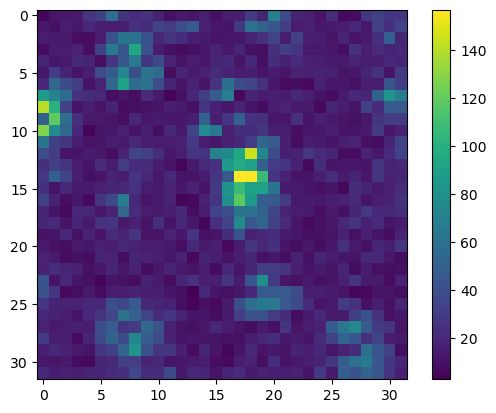

In [128]:
#Select a single repetition (second index here)
d3=np.asarray([data[0,10,:,:,:,i] for i in index3], dtype='float')
print('d3 format (ch,y,x,t) ' +str(d3.shape))
d3=np.transpose(d3,(1,2,3,0))
print('d3 format (y,x,t,ch): ' +str(d3.shape))

d5=np.asarray([data[0,0,:,:,:,i] for i in index5], dtype='float')
print('d5 format (ch,y,x,t) ' +str(d5.shape))
d5=np.transpose(d5,(1,2,3,0))
print('d5 format (y,x,t,ch): ' +str(d5.shape))

#sum over channels and time points of that repetition + plot it and write it
d5summed=d5.sum(axis=(2,3))
plt.imshow(d5summed[:,:])
plt.colorbar()
#imageio.imwrite(savename + ' d3 1rep channels summed.tiff', d3summed)
print(d5summed.shape)

In [130]:
#OR sum over repetitions  Data format (z,rep,y,x,t,ch)
d3=np.asarray([data[0,:,:,:,:,i] for i in index3], dtype='float')
d3=np.sum(d3,axis=1)
d3=np.transpose(np.asarray(d3),(1,2,3,0))
print('d3 format (y,x,t,ch): ' +str(d3.shape))

d5=np.asarray([data[0,0:20,:,:,:,i] for i in index5], dtype='float')
d5=np.sum(d5,axis=1)
d5=np.transpose(np.asarray(d5),(1,2,3,0))
print('d5 format (y,x,t,ch): ' +str(d5.shape))

d3 format (y,x,t,ch): (32, 32, 50, 9)
d5 format (y,x,t,ch): (32, 32, 50, 24)


In [17]:
#OR sum over time and repetitions Data format (z,rep,y,x,t,ch)
d5=np.asarray([data[0,0:20,:,:,:,i] for i in index5], dtype='float')
d5=np.sum(d5,axis=(1,4))
d5=np.transpose(np.asarray(d5),(1,2,0))
print('d5 format (y,x,ch): ' +str(d5.shape))


d5 format (y,x,ch): (64, 64, 24)


d3 format (y,x,t,rep,ch): (32, 32, 50, 50, 9)
(50, 50)


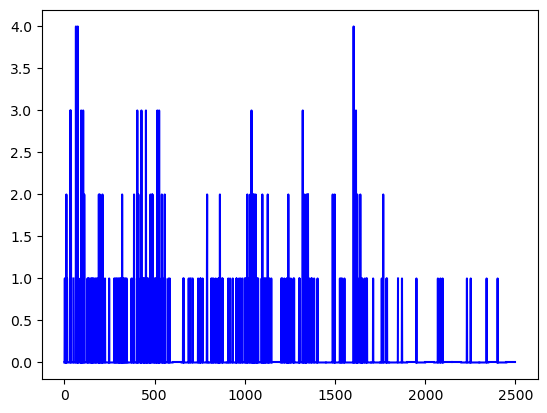

In [145]:
#plot timetraces of selected ROIs over timepoints and repetitions, if desired
d3=np.asarray([data[0,:,:,:,:,i] for i in index3], dtype='float')
d3=np.transpose(d3,(2,3,4,1,0))
print('d3 format (y,x,t,rep,ch): ' +str(d3.shape))

#cut=d3[15:30,40:50,:,:,:].sum(axis=(0,1,4))
cut=d3[13,17,:,:,4]
print(cut.shape)
for m in range(cut.shape[1]):
    plt.plot(np.arange(0+m*cut.shape[0],cut.shape[0]+m*cut.shape[0],1),cut[:,m],'b')


# Check Dataset

### Check fingerprint

(7, 7)


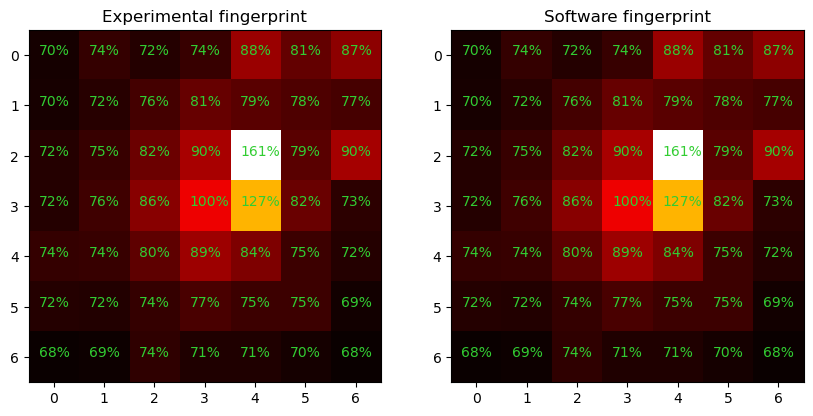

In [19]:
fingerprint = tool.fingerprint(data.sum(axis=(0,1,4)))
print(fingerprint.shape)
fingerprint[1,5]=(fingerprint[1,4]+fingerprint[1,6])/2 #smooth spad 12
fingerprint_meta[1,5]=(fingerprint_meta[1,4]+fingerprint_meta[1,6])/2
c= int((spadFormat-1)/2)  #change it if the maximum is not at the center

fig,ax= plt.subplots(1,2, figsize=(10,10))
ax[0].imshow(fingerprint, cmap='hot')
ax[1].imshow(fingerprint_meta, cmap='hot')
#plt.colorbar()
for i in range(7):
    for j in range(7):
        ax[0].text(j-0.3,i, str(round(fingerprint[i,j]*100/fingerprint[c,c])) + '%', color='limegreen')
        ax[0].set_title('Experimental fingerprint')
        ax[1].text(j-0.3,i, str(round(fingerprint_meta[i,j]*100/fingerprint_meta[c,c])) + '%', color='limegreen')
        ax[1].set_title('Software fingerprint')

#fig.savefig(savename + ' fingeprint.png')
#print(fingerprint)
#im = Image.fromarray(fingerprint)
#im.save(savename + ' fingerprint tif.tiff')

### Check Images stack

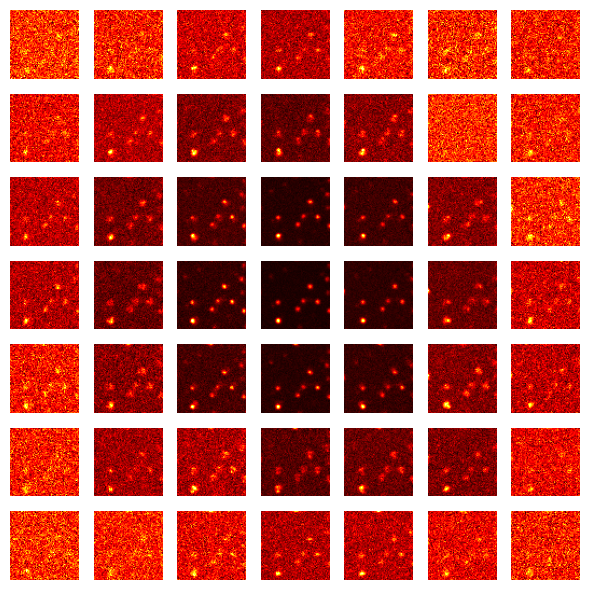

In [22]:
fig_1 = gra.ShowDataset(np.sum(data,axis=(0,1,4)),normalize = False, colorbar=False)
#fig_1 = gra.ShowImg(np.sum(data,axis=(0,1,4))[422:512,45:135,24], pxsize_x=pxsizex)#,normalize = False, colorbar=False)

To save a stack (timetraces, all channels, etc..) Fiji wants time/channel as first index, so we use transpose. <br><br> If you want to save the timetrace of SPAD X from repetition R, it's: $\;\;$ "np.transpose(data[0,R,:,:,:,X], axes=(2,0,1))" <br>  If you want to save the NxN images, it's:  $\;\;$ "np.transpose(d3.sum(axis=2), axes=(2,0,1))" <br> Careful about the difference between Data and d3/d5/etc.!

In [57]:
#Save central element time series (over all repetitions summed)
print('d3 format (y,x,t,ch): ' +str(d3.shape))
tifffile.imwrite(savename + ' central timetrace 1rep.tiff', np.transpose(d3[:,:,:,4], axes=(2,0,1)))

d3 format (y,x,t,ch): (512, 512, 50, 24)


In [233]:
#Save central element (time summed, over 1 repetition)
im = Image.fromarray(data[0,0,:,:,:,24].sum(axis=2).astype(np.uint8))
im.save(savename + ' central 1rep.tiff')

# Image reconstruction

The available datasets are: 

data [z,r,y,x,t,ch] <br> d3, d5,d1 [y,x,t,ch] <br>datacut [y,x,t,ch] (- spad 12)

## Confocal

In [1029]:
datacut=np.sum(np.delete(data, 12,5)[0,:,:,:,:],axis=(0))[...] #Remove SPAD 12
print(datacut.shape)

(64, 64, 50, 48)


(<Figure size 640x480 with 2 Axes>, <Axes: >)

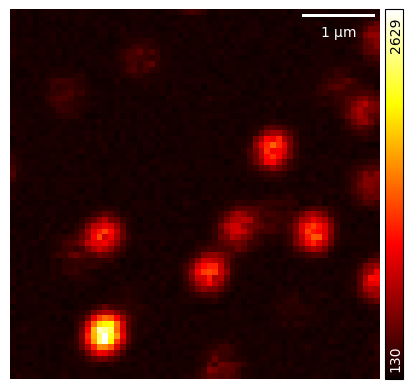

In [24]:
#img_sum = d3.sum(axis=(2,3))
img_sum = d5.sum(axis=(2))
gra.ShowImg(img_sum, pxsize_x = pxsizex)

In [242]:
im = Image.fromarray(img_sum)
im.save(savename + ' confocal d3.tiff')

## APR

Use a format [y,x,ch] for the data, remove time and repetions if present. Note: "shift_vec" is given in pixels, but apr.Reassignment later wants it in microns!

data -> ref = 24 <br> Datacut -> ref = 23 <br> d5 -> ref = 12 <br> d3 -> ref = 4 <br> d1 -> ref = 2

/Users/margauxbouzin/opt/anaconda3/lib/python3.9/site-packages/brighteyes_ism/analysis/Graph_lib.py:550: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(shift[:, 0], shift[:, 1], s=80, c=color, edgecolors='black', cmap=cmap)


Text(0.5, 1.0, 'Shift Vectors')

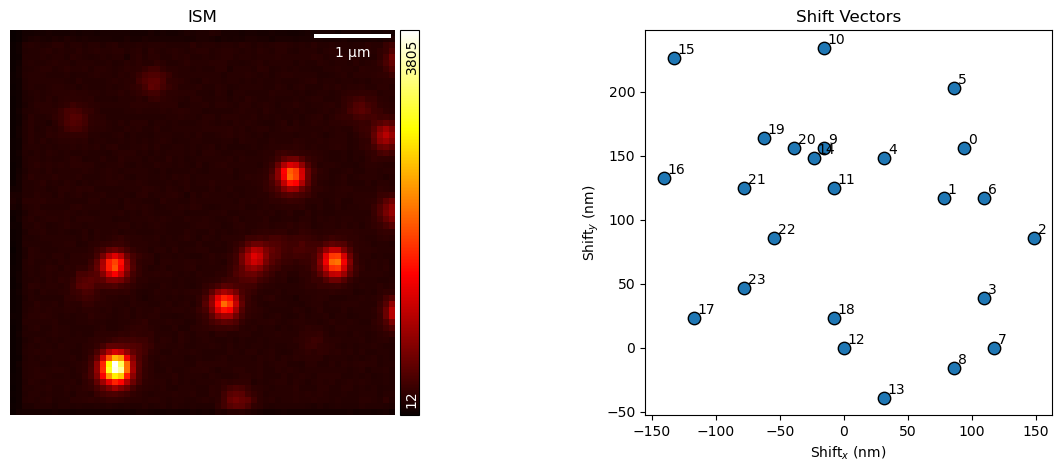

In [26]:
#ISM image
usf = 10  #upsampling factor = subpixel precision
ref = 12 #reference image to compute the shift vectors

#shift_vec5, img_ism = apr.APR(d5.sum(axis=(2)), usf, ref, filter_sigma=1, pxsize = pxsizex*1000) #pxsize in nm
shift_vec5, img_ism = apr.APR(d5, usf, ref, filter_sigma=1, pxsize = pxsizex*1000) #pxsize in nm
img_ism_sum = img_ism.sum(axis=-1)

fig, ax = plt.subplots(1, 2, figsize=(15,5))
gra.ShowImg(img_ism_sum, pxsize_x = pxsizex, fig = fig, ax = ax[0])
ax[0].set_title('ISM')
gra.PlotShiftVectors(shift_vec5, fig = fig, ax = ax[1])
#gra.PlotShiftVectors(shift_vec3, fig = fig, ax = ax[1],color='red',labels=False)
ax[1].set_title('Shift Vectors')
#ax[1].set_xlim(-400,500)
#ax[1].set_ylim(-300,400)

In [248]:
im = Image.fromarray(img_ism_sum)
im.save(savename + ' ISM d3.tiff')

#extent = ax[1].get_window_extent().transformed(fig.dpi_scale_trans.inverted())
#fig.savefig(savename + ' shift vectors d3.png', bbox_inches=extent.expanded(1.2, 1.2))

#Save all single images as a stack
#tifffile.imwrite(savename + ' shifted stack.tiff', np.transpose(img_ism, (2,0,1)))

Text(0.5, 1.0, 'ISM')

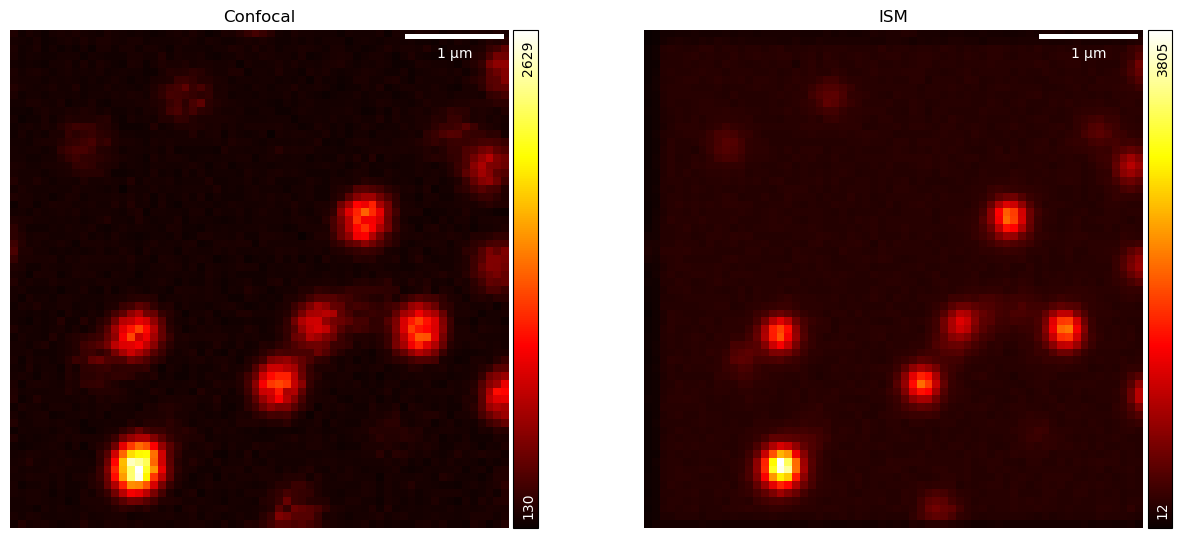

In [28]:
fig, ax = plt.subplots(1, 2, figsize=(15,10))

gra.ShowImg(img_sum[:,:], pxsize_x = pxsizex, fig = fig, ax = ax[0]) #[422:512,45:135]
ax[0].set_title('Confocal')

gra.ShowImg(img_ism_sum[:,:], pxsize_x = pxsizex, fig = fig, ax = ax[1]) #[320:356,206:242]
ax[1].set_title('ISM')

(100, 64, 64, 50)


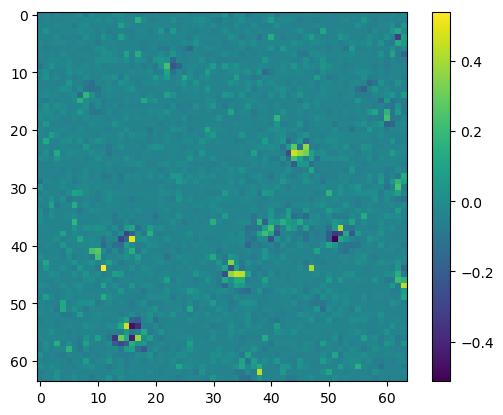

In [30]:
## Temporal correlations
## Data format (z,rep,y,x,t,ch) (1, 100, 64, 64, 50, 49)

def correlazione(t1,m1,t2,m2):
    fft1=scipy.fftpack.fft([(t1[i])-m1 for i in range(len(t1))])
    fft2=scipy.fftpack.fft([(t2[i])-m2 for i in range(len(t2))])
    fft1=np.ma.conjugate(fft1)
    crosscorr=np.real(scipy.fftpack.ifft(fft1*fft2))#/(m1*m2*len(t1)))
    return crosscorr

#prove di autocorr su elemento centrale

central=np.asarray(data[0,:,:,:,:,24], dtype='float')
print(central.shape)

img_autocorr=np.zeros((central.shape[1],central.shape[2],central.shape[3]), dtype='float')
for i in range(central.shape[1]):
    for j in range(central.shape[2]):
        count=0
        for r in range(central.shape[0]):
            if np.mean(central[r,i,j,:])!=0:
                count=count+1
                img_autocorr[i,j,:]=img_autocorr[i,j,:]+correlazione(central[r,i,j,:],np.mean(central[r,i,j,:]),central[r,i,j,:],np.mean(central[r,i,j,:]))
        if count!=0:
            img_autocorr[i,j,:]=img_autocorr[i,j,:]/count
plt.imshow(img_autocorr[:,:,1])            
plt.colorbar()

Text(0.5, 1.0, 'central element SOFI')

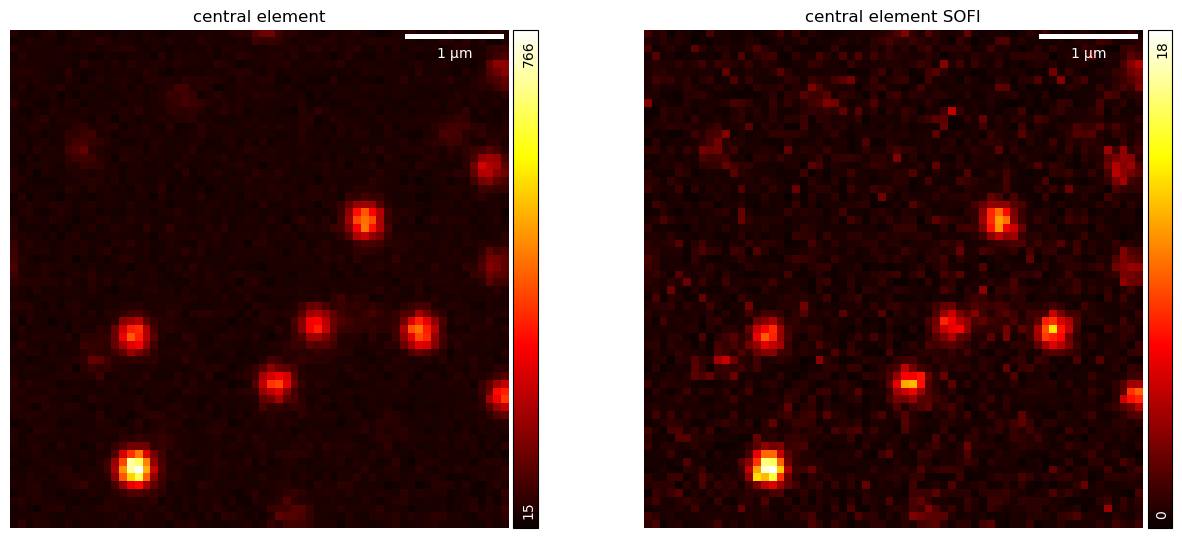

In [31]:
fig, ax = plt.subplots(1, 2, figsize=(15,10))
gra.ShowImg(np.sum(central,axis=(0,3)), pxsize_x = pxsizex, fig = fig, ax = ax[0]) #[422:512,45:135]
ax[0].set_title('central element')
gra.ShowImg(img_autocorr[:,:,0], pxsize_x = pxsizex, fig = fig, ax = ax[1]) #[320:356,206:242]
ax[1].set_title('central element SOFI')

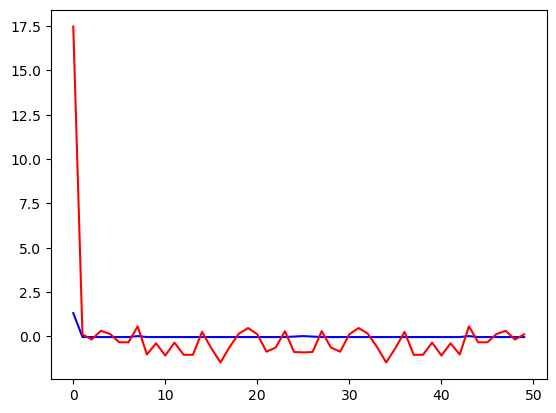

In [1057]:
plt.plot(np.arange(0,img_autocorr.shape[2],1),img_autocorr[60,3,:],'b')
plt.plot(np.arange(0,img_autocorr.shape[2],1),img_autocorr[56,15,:],'r')
#plt.plot(np.arange(0,img_autocorr.shape[2],1),central[0,56,15,:])

In [1101]:
## SOFISM
## Data format (z,rep,y,x,t,ch) (1, 100, 64, 64, 50, 49)

def correlazione(t1,m1,t2,m2):
    fft1=scipy.fftpack.fft([(t1[i])-m1 for i in range(len(t1))])
    fft2=scipy.fftpack.fft([(t2[i])-m2 for i in range(len(t2))])
    fft1=np.ma.conjugate(fft1)
    crosscorr=np.real(scipy.fftpack.ifft(fft1*fft2)/(m1*m2*len(t1)))
    return crosscorr

#imgN=int(49*48/2)
#paircorr=np.zeros((data.shape[2],data.shape[3],data.shape[4],imgN), dtype='float')
#chindex=-1
#for ch1 in range(49):
#    for ch2 in range(ch1+1,49,1):
#        chindex=chindex+1
#        for i in range(data.shape[2]):
#            for j in range(data.shape[3]):
#                count=0
#                for r in range(data.shape[1]):
#                    if np.mean(data[0,r,i,j,:,ch1])!=0 and np.mean(data[0,r,i,j,:,ch2])!=0:
#                        count=count+1
#                        paircorr[i,j,:,chindex]=paircorr[i,j,:,chindex]+correlazione(data[0,r,i,j,:,ch1],np.mean(data[0,r,i,j,:,ch1]),data[0,r,i,j,:,ch2],np.mean(data[0,r,i,j,:,ch2]))
#                paircorr[i,j,:,chindex]=paircorr[i,j,:,chindex]/count
#plt.imshow(paircorr[:,:,0,24])            
#plt.colorbar()   

dataset=np.asarray([data[:,:,:,:,:,i] for i in index3], dtype='float')
dataset=np.transpose(dataset,(1,2,3,4,5,0))
print(dataset.shape)
imgN=int(9*8/2)
paircorr=np.zeros((dataset.shape[2],dataset.shape[3],dataset.shape[4],imgN), dtype='float')
chindex=-1
for ch1 in range(9):
    for ch2 in range(ch1+1,9,1):
        chindex=chindex+1
        print(ch1,ch2,chindex)
        for i in range(dataset.shape[2]):
            for j in range(dataset.shape[3]):
                count=0
                for r in range(dataset.shape[1]):
                    if (np.mean(dataset[0,r,i,j,:,ch1])!=0 and np.mean(dataset[0,r,i,j,:,ch2])!=0):
                        count=count+1
                        paircorr[i,j,:,chindex]=paircorr[i,j,:,chindex]+correlazione(dataset[0,r,i,j,:,ch1],np.mean(dataset[0,r,i,j,:,ch1]),dataset[0,r,i,j,:,ch2],np.mean(dataset[0,r,i,j,:,ch2]))
                if count!=0:
                    paircorr[i,j,:,chindex]=paircorr[i,j,:,chindex]/count



(1, 100, 64, 64, 50, 9)
0 1 0
0 2 1
0 3 2
0 4 3
0 5 4
0 6 5
0 7 6
0 8 7
1 2 8
1 3 9
1 4 10
1 5 11
1 6 12
1 7 13
1 8 14
2 3 15
2 4 16
2 5 17
2 6 18
2 7 19
2 8 20
3 4 21
3 5 22
3 6 23
3 7 24
3 8 25
4 5 26
4 6 27
4 7 28
4 8 29
5 6 30
5 7 31
5 8 32
6 7 33
6 8 34
7 8 35


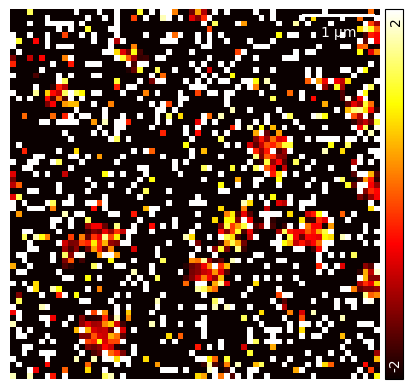

In [1121]:
#fig_1 = gra.ShowDataset(np.sum(dataset,axis=(0,1,4)),normalize = True, colorbar=True)
#fig_1 = gra.ShowDataset(paircorr[:,:,0,:],normalize = False, colorbar=True)
fig_1 = gra.ShowImg(paircorr[:,:,0,21], pxsize_x=pxsizex,vmax=2)#,normalize = False, colorbar=False)

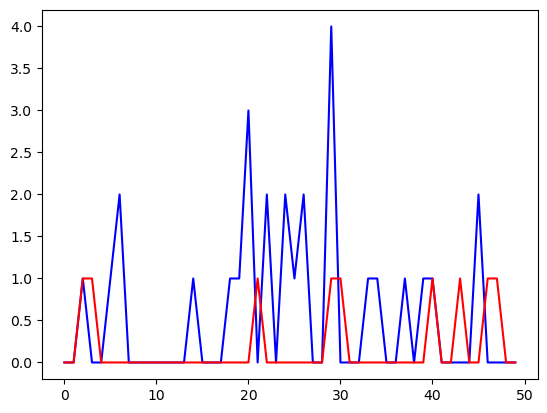

In [1109]:
plt.plot(np.arange(0,dataset.shape[4],1),dataset[0,3,56,15,:,4],'b')
plt.plot(np.arange(0,dataset.shape[4],1),dataset[0,3,56,15,:,3],'r')

## Deconvolution

### Open experimental PSF

Open a tiff stack of the 49 PSFs and resize them to the same pixel size and number of pixels of the image

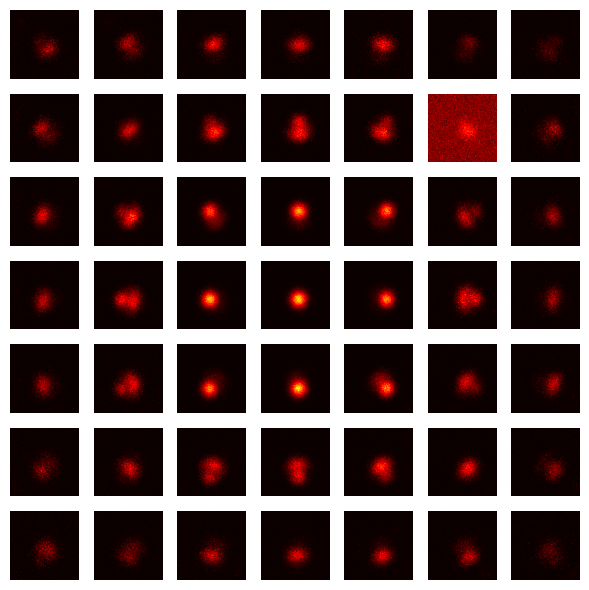

In [15]:
psf_exp=tifffile.imread('/Users/margauxbouzin/Library/CloudStorage/GoogleDrive-margaux.bouzin@unimib.it/Drive condivisi/BioPhotonics/Riccardo/Clara tesi/dati 2024 11 19 sfere 170nm xy/170nm 5micron 220mW 50rep stack.tiff')
psf_fov = 5 #micron
psf_format = 512
psf_exp =np.transpose(psf_exp, (1,2,0))
figx = gra.ShowDataset(psf_exp[160:360,160:360,:], normalize=False, colorbar=True)

In [16]:
psf_pxsize = psf_fov/psf_format
rap=pxsizex/psf_pxsize
l= round(psf_format/rap)
psf_exp=cv2.resize(psf_exp.astype(float), (l,l))
psf_pxsize = psf_fov/psf_exp.shape[0]

pd= round((img_sum.shape[0]-psf_exp.shape[0])/2)
pd2=(img_sum.shape[0]-psf_exp.shape[0])-pd
psf_exp=np.pad(psf_exp,((pd,pd2),(pd,pd2),(0,0)), 'constant')
print("PSF format: " + str(psf_exp.shape))
print("image format: " + str(data.shape))
print("PSF pixel: " + str(psf_pxsize))
print("img pixel: " + str(pxsizex))

PSF format: (512, 512, 49)
image format: (1, 1, 512, 512, 50, 49)
PSF pixel: 0.049019607843137254
img pixel: 0.048828125


 <br>Define psfcut, psf_d3, etc. as for the image

In [17]:
psfcut=np.delete(psf_exp, 12,2) #Remove SPAD 12
print(psfcut.shape)

psf_d5 =np.transpose(np.asarray([psf_exp[:,:,i] for i in index5]),axes=(1,2,0))
print(psf_d5.shape)

(512, 512, 48)
(512, 512, 24)


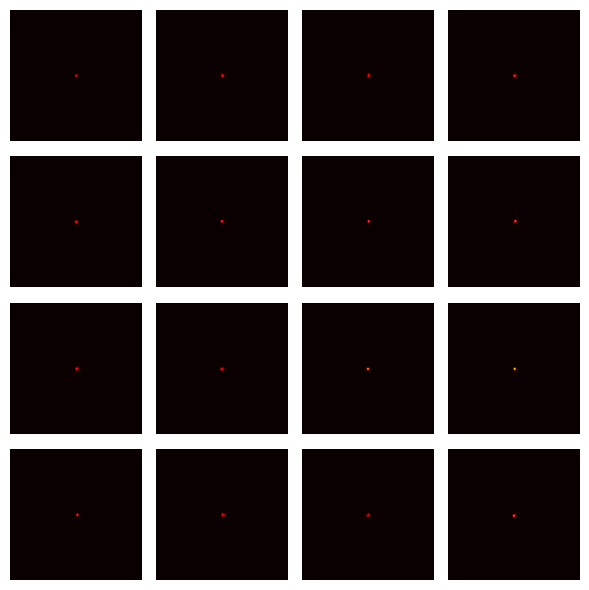

In [18]:
fig_x = gra.ShowDataset(psf_d5[:,:,:],normalize = False, colorbar=False)

### Deconvolve

if out='all' the result is a stack of the iterations, select img_deconv[-1,x,y]. If out='last',it gives only the final iteration [x,y]

In [266]:
print(psf_d3.shape)
print(d3.shape)

(512, 512, 9)
(512, 512, 50, 9)


Multi-image deconvolution:


100%|███████████████████████████████████████████| 10/10 [00:16<00:00,  1.68s/it]


(<Figure size 640x480 with 2 Axes>, <Axes: >)

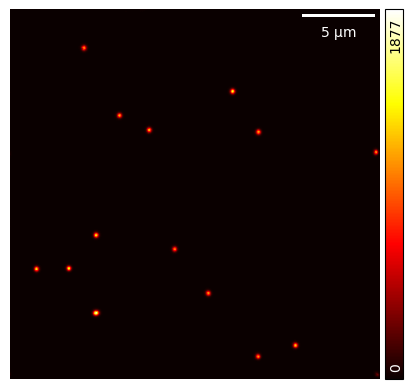

In [19]:
#classical deconvolutin
img_deconv = dec.MultiImg_RL_FFT(psfcut, datacut.sum(axis=(2)), max_iter = 10, reg=0, out='all') #all or last
gra.ShowImg(img_deconv[-1,...], pxsize_x = pxsizex)

In [270]:
print(img_sum.shape)

(512, 512)


Text(0.5, 1.0, 'Deconvolution')

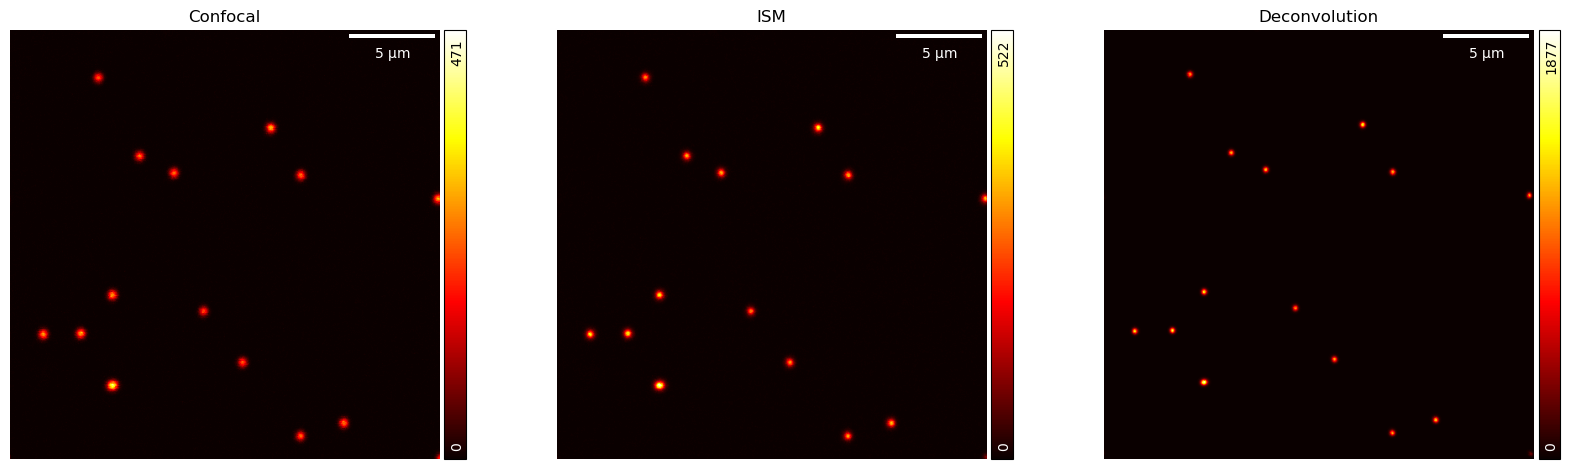

In [20]:
fig, ax = plt.subplots(1, 3, figsize=(20,20))
gra.ShowImg(img_sum, pxsize_x = pxsizex, fig = fig, ax = ax[0])
ax[0].set_title('Confocal')
gra.ShowImg(img_ism_sum, pxsize_x = pxsizex, fig = fig, ax = ax[1])
ax[1].set_title('ISM')
gra.ShowImg(img_deconv[-1,:,:], pxsize_x = pxsizex, fig = fig, ax = ax[2])
ax[2].set_title('Deconvolution')

In [291]:
#Save all iterations
tifffile.imwrite(savename + ' deconv all-iter.tiff', img_deconv[-1,:,:])

In [278]:
im = Image.fromarray(img_deconv[-1,...])
im.save(savename + ' deconv d3.tiff')

## ISM-SRRF

In [172]:
#Open ISS Tiff image if needed
img_iss=np.asarray(Image.open('/Users/margauxbouzin/Library/CloudStorage/GoogleDrive-margaux.bouzin@unimib.it/Drive condivisi/BioPhotonics/Riccardo/Clara tesi/dati 2024 11 19 sfere 170nm xy/170nm 25micron 100mW 30rep ISS.tif'))
pxsizex=0.0488

Define magnification and radius as variables so every method uses the same values

In [1063]:
magn=2
radius=6

For applying reassignment between SRRF steps, we take the shift that were previously found from the "classical" reconstruction. NOTE: if APR was done a 3x3, the shifts here will be a 3x3 as well! Pay attention that the images and the shift have the same format when doing reassignment!

In [1066]:
shift5=shift_vec5/(pxsizex*1000)
print('5x5 shift vectors shape: ' + str(shift5.shape))

5x5 shift vectors shape: (24, 2)


### 1) ISM->Radiality

Here, we take the ISM reconstructed image img_ism_sum (or the deconvolved image img_deconv) and calculate only the radiality map. <br><br> NOTE: srrf_ism_1 has an additional index for time at the beginning. When showing the image, use "srrf_ism_1[0,x,y]"

In [1069]:
srrf_ism_1 = eSRRF(np.ascontiguousarray(img_ism_sum[...]), magnification=magn,radius=radius,doIntensityWeighting=True)[0]
print(srrf_ism_1.shape)

Agent: eSRRF_ST using opencl ran in 0.1930312079966825 seconds
(128, 128)


Text(0.5, 1.0, 'spatial SRRF over summed ISM')

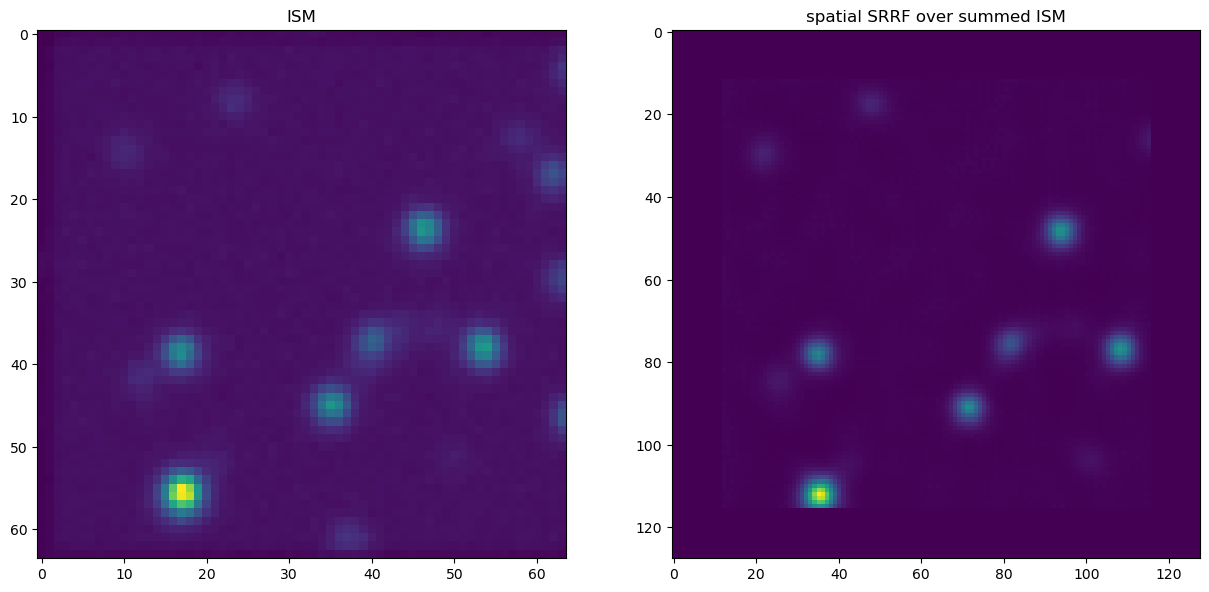

In [1070]:
fig, ax = plt.subplots(1,2,figsize=(15,15)) 
#ax[0].imshow(img_deconv[-1,...],vmax=400)
ax[0].imshow(img_ism_sum[...])
ax[0].set_title('ISM')
ax[1].imshow(srrf_ism_1[...])#,vmax=120)
ax[1].set_title('spatial SRRF over summed ISM')

In [339]:
im = Image.fromarray(srrf_ism_1)
im.save(savename + ' SRRF magn1 radius12.tiff')

### 2) ISM->SRRF

First, do pixel reassignment for every timeframe, obtaining a sequence of ISM images (ttrace_ism [x,y,t]). Then we measure radiality and apply the temporal analysis

For temporal analysis we have three possibilities: AVG makes an average of the radiality, VAR takes the variance, TAC2 computes the second order autocorrelation

In [87]:
ttrace_ism = np.zeros(d5.shape)

for i in tqdm(range(ttrace_ism.shape[2])):  #iterate over time bins
    ttrace_ism[:,:,i,:]=apr.Reassignment(shift5,d5[:,:,i,:])
ttrace_ism=np.sum(ttrace_ism, axis=(-1))
print('ttrace_ism format [x,y,t]: ' +str(ttrace_ism.shape))

100%|██████████| 50/50 [00:00<00:00, 66.28it/s]

ttrace_ism format [x,y,t]: (64, 64, 50)


In [310]:
#tifffile.imwrite(savename + ' ism d3 timetrace.tiff', np.transpose(ttrace_ism, axes=(2,0,1)))

Text(0.5, 1.0, 'classical ism')

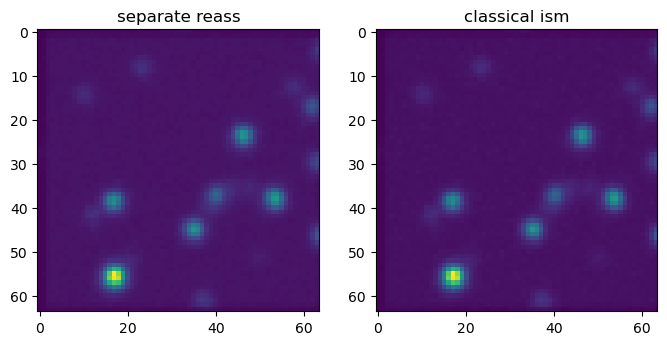

In [91]:
#Check that, summing over time, the image is the same to the previous reassigned image

fig, ax = plt.subplots(1, 2, figsize=(8,8))
ax[0].imshow(ttrace_ism.sum(axis=(-1)))
ax[0].set_title('separate reass')
ax[1].imshow(img_ism_sum)
ax[1].set_title('classical ism')

In [93]:
#Here we do the radiality map and the temporal analysis

rad_ism_2 = np.transpose(np.zeros((ttrace_ism.shape)), axes=(2,0,1))
srrf_ism_2 = np.zeros(ttrace_ism.shape[:2])

rad_ism_2[:,:,:] = eSRRF(np.ascontiguousarray(np.transpose(ttrace_ism[:,:,:],axes=(2,0,1))), magnification=magn,radius=radius)[0]
srrf_ism_2[:,:] = calculate_eSRRF_temporal_correlations(rad_ism_2[...], 'AVG')


Agent: eSRRF_ST using opencl ran in 0.11520958300002349 seconds


ValueError: could not broadcast input array from shape (128,128) into shape (50,64,64)

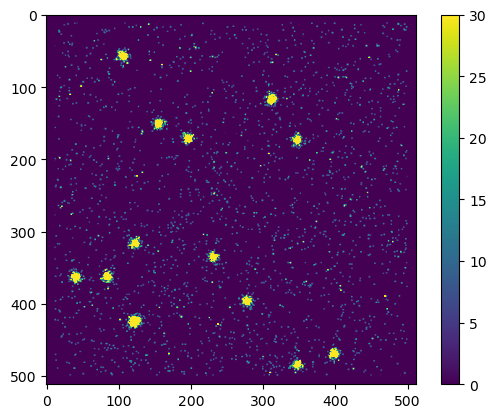

In [352]:
plt.imshow(srrf_ism_2[...],vmin=0,vmax=30)
plt.colorbar()

In [311]:
im = Image.fromarray(srrf_ism_2)
im.save(savename + ' SRRF_ismtrace.tiff')

### 3) SRRF->ISM

Here we apply SRRF to the time sequence of every spad, obtaining N SRRF images that we will then reassign

In [1073]:
d3=np.asarray([data[0,0:20,:,:,:,i] for i in index3], dtype='float')
d3=np.sum(d3,axis=(1))
d3=np.transpose(np.asarray(d3),(1,2,3,0))
print('d3 format (y,x,t,ch): ' +str(d3.shape))

rad_d3= np.zeros((d3.shape[2],magn*d3.shape[0],magn*d3.shape[1],d3.shape[3]),dtype='float')#np.transpose(np.zeros(d3.shape),axes=(2,0,1,3))
print('rad_d3 format (t,y,x,ch): ' +str(rad_d3.shape))

srrf_d3= np.zeros((rad_d3.shape[1],rad_d3.shape[2],rad_d3.shape[3]))
print('srrf_d3 format (y,x,ch): ' +str(srrf_d3.shape))

for i in range(d3.shape[3]):
    #print(eSRRF(np.ascontiguousarray(np.transpose(d3[:,:,:,i],axes=(2,0,1))), magnification=magn,radius=radius).shape)
    rad_d3[:,:,:,i] = eSRRF(np.ascontiguousarray(np.transpose(d3[:,:,:,i],axes=(2,0,1))), magnification=magn,radius=radius)  
    srrf_d3[:,:,i] = calculate_eSRRF_temporal_correlations(rad_d3[:,:,:,i], 'VAR')

d3 format (y,x,t,ch): (64, 64, 50, 9)
rad_d3 format (t,y,x,ch): (50, 128, 128, 9)
srrf_d3 format (y,x,ch): (128, 128, 9)
Agent: eSRRF_ST using opencl ran in 0.09261804099878646 seconds
Agent: eSRRF_ST using opencl ran in 0.08185920799951418 seconds
Agent: eSRRF_ST using opencl ran in 0.0906722500003525 seconds
Agent: eSRRF_ST using opencl ran in 0.08657345800020266 seconds
Agent: eSRRF_ST using opencl ran in 0.08283904100244399 seconds
Agent: eSRRF_ST using opencl ran in 0.07486754199999268 seconds
Agent: eSRRF_ST using opencl ran in 0.0850950419990113 seconds
Agent: eSRRF_ST using opencl ran in 0.08339004200024647 seconds
Agent: eSRRF_ST using opencl ran in 0.08409899999969639 seconds


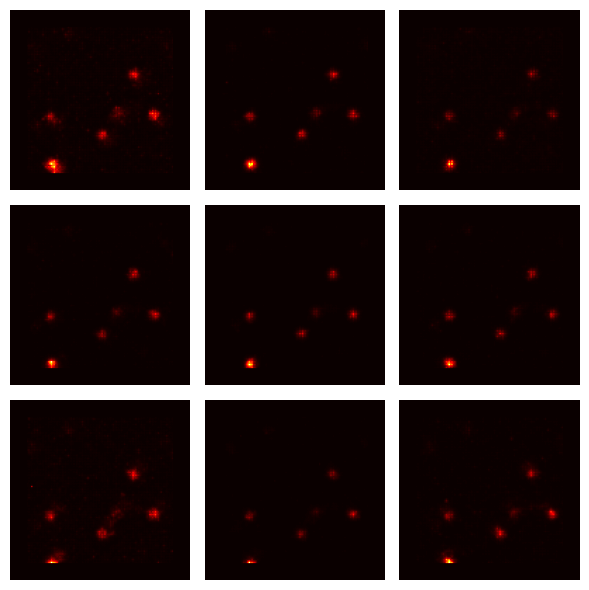

In [1075]:
fig_1 = gra.ShowDataset(srrf_d3,normalize = False, colorbar=False)

Text(0.5, 1.0, 'central SRRF')

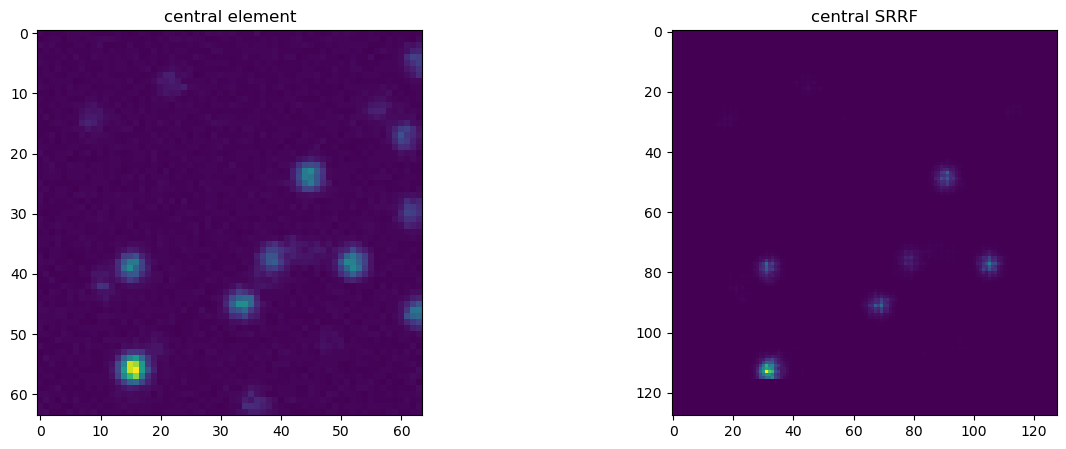

In [1077]:
# Compare the central element intensity image with its SRRF counterpart
fig, ax = plt.subplots(1, 2, figsize=(15,5))
ax[0].imshow(d3.sum(axis=(2))[:,:,4])
ax[0].set_title('central element')
ax[1].imshow(srrf_d3[:,:,4], vmin=0)
ax[1].set_title('central SRRF')

Here we do the reassignment. NOTE: We can use shift3 only if the magnification is 1! if magnification>1, we have to do apr.APR and re-compute the shift, or rescale the shifts in some way

Text(0.5, 1.0, 'Shift Vectors')

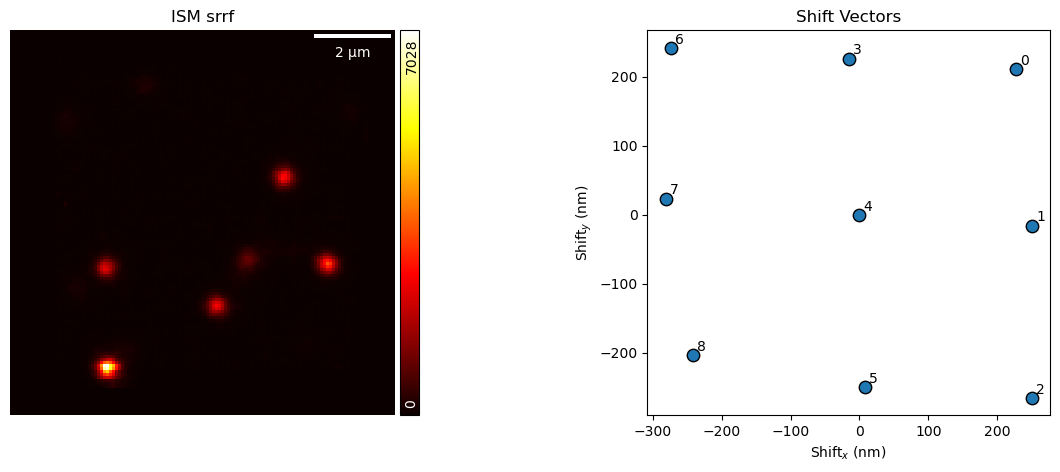

In [1079]:
#srrf_ism_3 =apr.Reassignment(shift3,srrf_d3)
#srrf_ism_3 = srrf_ism_3.sum(axis=-1)

#fig, ax = plt.subplots(1, 2, figsize=(15,5))
#ax[0].imshow(srrf_ism_3[...],vmax=50)
#ax[0].set_title('Reassigned SRRF')
#ax[1].imshow(img_ism_sum, vmax=50)
#ax[1].set_title('ISM comparison')

usf = 10  #upsampling factor = subpixel precision
ref = 4 #reference image to compute the shift vectors
shift_vec3_srrf, img_ism_srrf = apr.APR(srrf_d3, usf, ref, filter_sigma=1, pxsize = pxsizex*1000) #pxsize in nm
img_ism_sum_srrf = img_ism_srrf.sum(axis=-1)

fig, ax = plt.subplots(1, 2, figsize=(15,5))
gra.ShowImg(img_ism_sum_srrf, pxsize_x = pxsizex, fig = fig, ax = ax[0])
ax[0].set_title('ISM srrf')
gra.PlotShiftVectors(shift_vec3_srrf, fig = fig, ax = ax[1])
#gra.PlotShiftVectors(shift_vec3, fig = fig, ax = ax[1],color='red',labels=False)
ax[1].set_title('Shift Vectors')
#ax[1].set_xlim(-400,500)
#ax[1].set_ylim(-300,400)

Text(0.5, 1.0, 'ISM + time srrf')

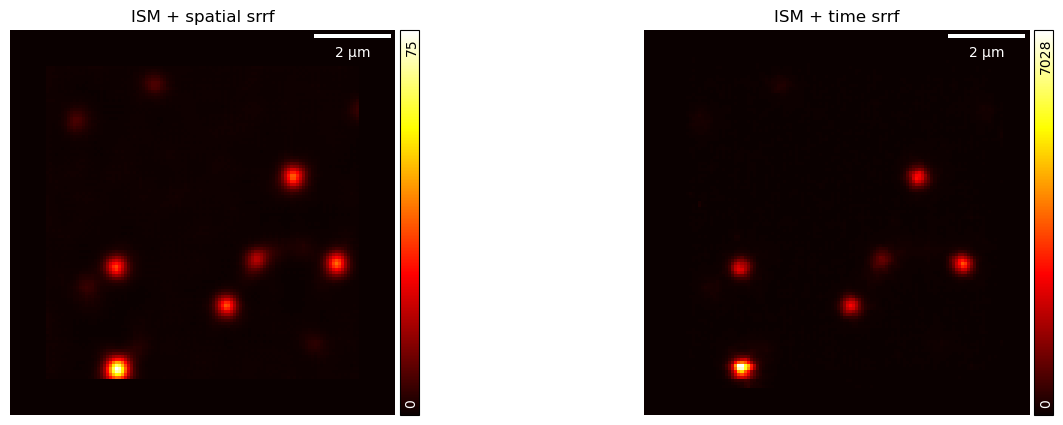

In [1081]:
fig, ax = plt.subplots(1, 2, figsize=(15,5))
gra.ShowImg(srrf_ism_1, pxsize_x = pxsizex, fig = fig, ax = ax[0])
ax[0].set_title('ISM + spatial srrf')
gra.ShowImg(img_ism_sum_srrf, pxsize_x = pxsizex, fig = fig, ax = ax[1])
#gra.PlotShiftVectors(shift_vec3, fig = fig, ax = ax[1],color='red',labels=False)
ax[1].set_title('ISM + time srrf')

In [292]:
im = Image.fromarray(srrf_ism_3)
im.save(savename + ' SRRF-apr.tiff')


## Results

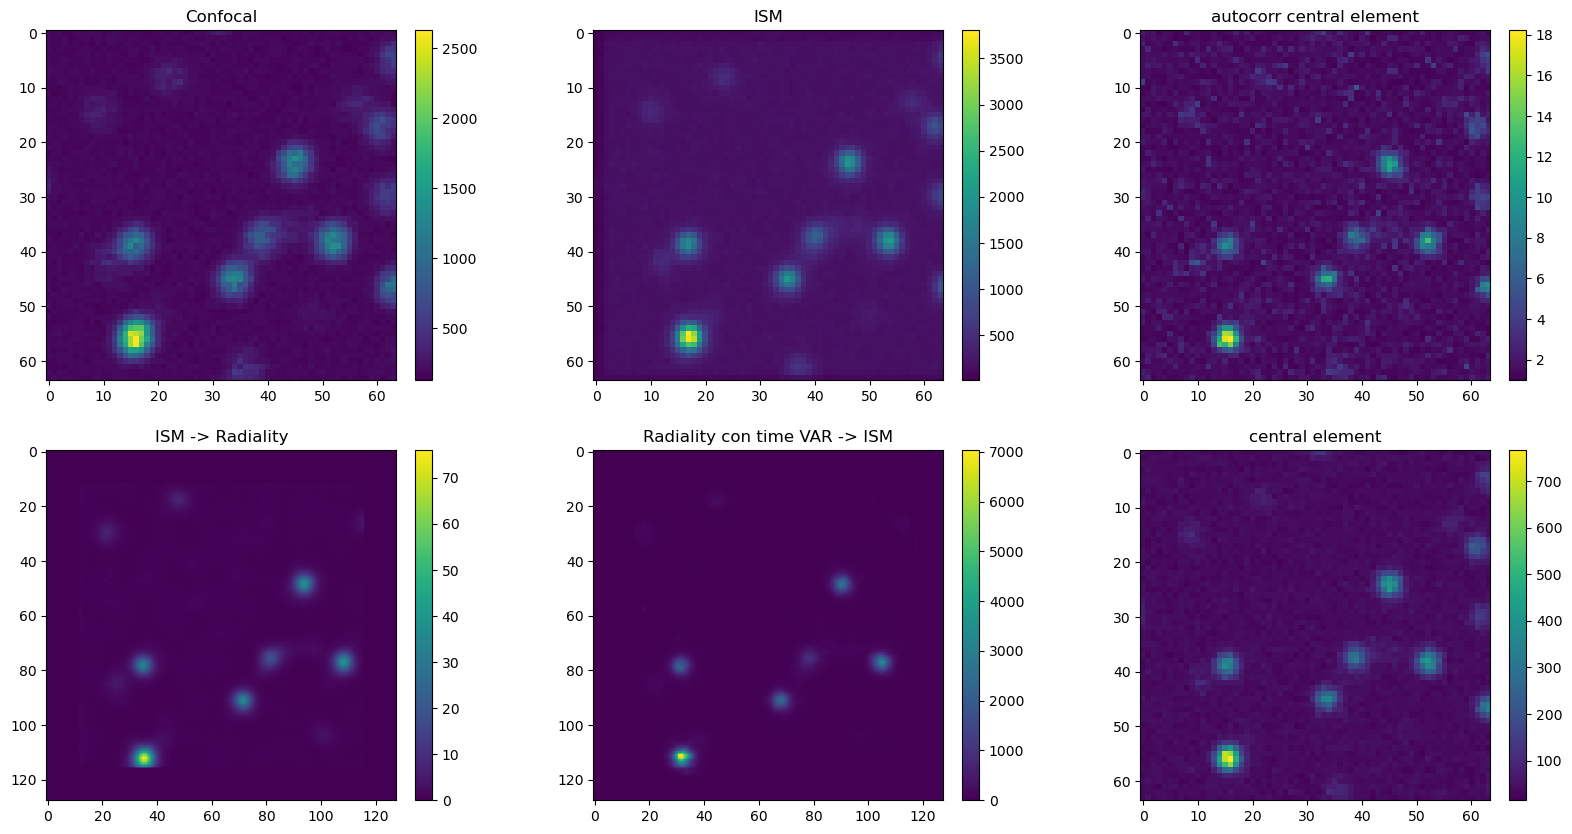

In [1083]:
fig, ax = plt.subplots(2,3, figsize=(20,10))
plt.subplots_adjust(hspace=0.2)

ax1 = ax[0,0].imshow(img_sum)
ax[0,0].set_title('Confocal')
fig.colorbar(ax1,fraction=0.046, pad=0.04)

ax2=ax[0,1].imshow(img_ism_sum)
ax[0,1].set_title('ISM')
fig.colorbar(ax2,fraction=0.046, pad=0.04)

ax3=ax[0,2].imshow(img_autocorr[:,:,0])#img_deconv[-1,300:450,0:150]) 
ax[0,2].set_title('autocorr central element')
fig.colorbar(ax3,fraction=0.046, pad=0.04)

ax4=ax[1,0].imshow(srrf_ism_1)
ax[1,0].set_title('ISM -> Radiality')
fig.colorbar(ax4,fraction=0.046, pad=0.04)

ax5=ax[1,1].imshow(img_ism_sum_srrf)
ax[1,1].set_title('Radiality con time VAR -> ISM')
fig.colorbar(ax5,fraction=0.046, pad=0.04)

ax6=ax[1,2].imshow(np.sum(central,axis=(0,3)))
ax[1,2].set_title('central element')
fig.colorbar(ax6,fraction=0.046, pad=0.04)

# Resolution measurement

In [828]:
img_1 = srrf_ism_1#img_sum#np.sum(data,axis=(0,1,4))[:,:,24]#img_deconv[-1,...] #insert here the images 1 and 2 that you want to analyse
img_2 = img_ism_sum_srrf#img_ism_sum#srrf_ism_1[...]

In [218]:
#img_1=tifffile.imread("C:/Users/rbolz/Downloads/qdots confocal repsum.tif")
#img_2=img_deconv[-1,...]

## Find peaks

In [830]:
xc=peak_local_max(img_1,min_distance=5, threshold_abs=13)

maxvalues=np.zeros(xc.shape[0],dtype='float')
for i in range(xc.shape[0]):
    maxvalues[i]=img_1[xc[i,0],xc[i,1]]

    xc1=np.zeros((xc.shape[0],2))
n=0
print(maxvalues)
for i in range(xc.shape[0]):
    if 8000>maxvalues[i]>13: #Change value range based on typical values of the variable "maxvalues", printed below
        xc1[n,:]=xc[i,:]
        n+=1       
xc1=xc1[0:n,:]

[75.98334503 39.99942017 37.5498085  37.02751923 35.14496613 19.37605476]


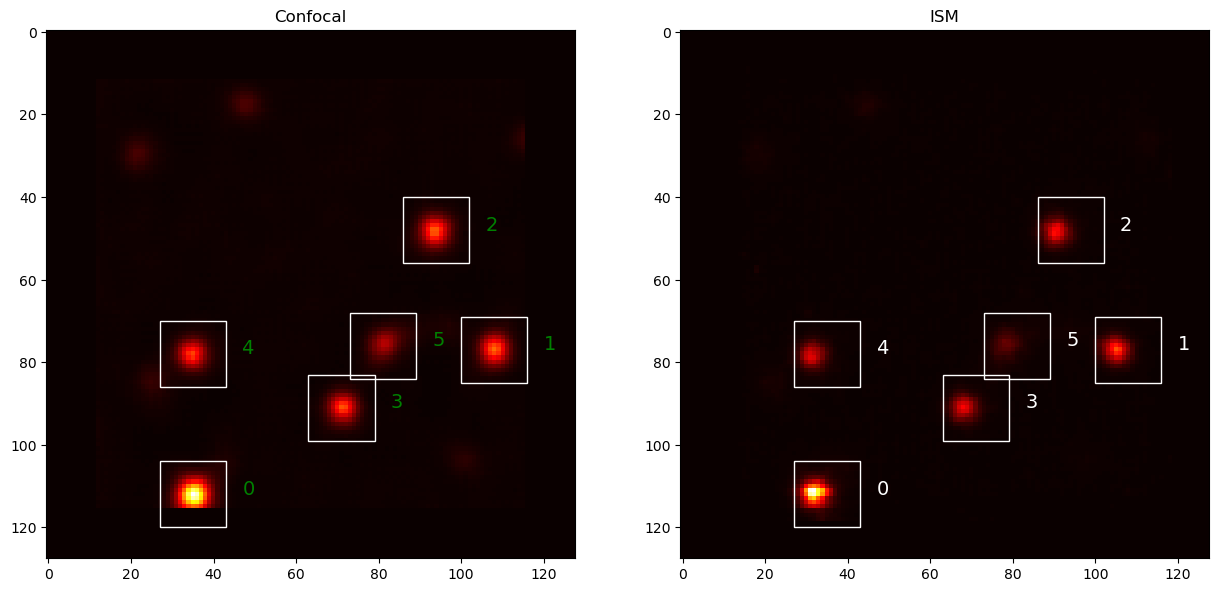

In [836]:
ROIsizeC = 16
Npart = xc1.shape[0]
fig, ax = plt.subplots(1, 2, figsize=(15,15))

ax[0].imshow(img_1,cmap='hot')#, vmax=300)
#ax[0].scatter(xc1[:,1],xc1[:,0])
ax[0].set_title('Confocal')
for l in range(Npart):
    rect = Rectangle((xc1[l,1]-ROIsizeC/2,xc1[l,0]-ROIsizeC/2),ROIsizeC,ROIsizeC,linewidth=1,edgecolor='w',facecolor='none')
    ax[0].add_patch(rect)
    ax[0].text(xc1[l,1]+4+ROIsizeC/2, xc1[l,0], l, fontsize=14, color='green')
    
ax[1].imshow(img_2,cmap='hot')#, vmax=50)
ax[1].set_title('ISM')
for l in range(Npart):
    rect = Rectangle((xc1[l,1]-ROIsizeC/2,xc1[l,0]-ROIsizeC/2),ROIsizeC,ROIsizeC,linewidth=1,edgecolor='w',facecolor='none')
    ax[1].add_patch(rect)
    ax[1].text(xc1[l,1]+4+ROIsizeC/2, xc1[l,0], l, fontsize=14, color='white')   
ax = plt.gca()

In [808]:
# Remove specific particles
#Refresh the image above to see the updated indexes after every deletion!

xc1=np.delete(xc1,[6],0)
Npart = xc1.shape[0]

## Particle Fit

In [786]:
def erfC(x, amp, xc, w, offset):
    fitfunction=amp*w*w*np.pi*(1-scipy.special.erf((xc-x)/(np.sqrt(2.0)*w)))+offset*ROIsizeC*x
    return fitfunction

In [846]:
magn=1
res_conf=np.zeros((Npart,3))
res_ism=np.zeros((Npart,3))
integrali_conf=np.zeros((Npart,ROIsizeC,2))
integrali_ism=np.zeros((Npart,ROIsizeC,2))

for l in range(0,Npart,1): #inizia il loop sulle particelle
    
    ROItemp_conf=np.zeros((ROIsizeC,ROIsizeC),dtype='float')
    ROItemp_ism=np.zeros((ROIsizeC,ROIsizeC),dtype='float')
    yi= (xc1[l,1]-ROIsizeC/2).astype(int)
    yf= (xc1[l,1]+ROIsizeC/2).astype(int)
    xi= (xc1[l,0]-ROIsizeC/2).astype(int)
    xf= (xc1[l,0]+ROIsizeC/2).astype(int)
    
    for i in range(xi,xf,1): #crea la ROI attorno alla NP
        for j in range(yi,yf,1):
            ROItemp_conf[i-xi][j-yi]=img_1[i][j]
            ROItemp_ism[i-xi][j-yi]=img_2[i][j]
    #plt.imshow(ROItemp_conf.T)
    
    integral_conf=np.zeros(ROIsizeC+1,dtype='float')
    integral_ism=np.zeros(ROIsizeC+1,dtype='float')
    axisC=np.zeros(ROIsizeC+1,dtype='float')
    
    for i in range(ROIsizeC+1):
        axisC[i]=i
        
    for i in range(ROIsizeC):   
        for j in range(ROIsizeC):
            integral_conf[i]=integral_conf[i]+ROItemp_conf[j][i]
            integral_ism[i]=integral_ism[i]+ROItemp_ism[j][i]
        integral_conf[i+1]=integral_conf[i]
        integral_ism[i+1]=integral_ism[i]
            
    popt1, pcov1 = curve_fit(erfC, axisC, integral_conf, bounds=(0,np.inf), p0=(1005,5,2,10))
    popt2, pcov2 = curve_fit(erfC, axisC, integral_ism, bounds=(0,np.inf), p0=(1005,5,2,10))
    
    res_conf[l,0]=res_ism[l,0]=l
    res_conf[l,1]=popt1[2]*pxsizex*2.35/magn
    res_ism[l,1]=popt2[2]*pxsizex*2.35/magn
    res_conf[l,2]=popt1[0]
    res_ism[l,2]=popt2[0]
    
    
    for i in range(ROIsizeC):
        integrali_conf[l,i,0]=integral_conf[i]
        integrali_conf[l,i,1]=erfC(axisC,*popt1)[i]
        integrali_ism[l,i,0]=integral_ism[i]
        integrali_ism[l,i,1]=erfC(axisC,*popt2)[i]
    
print('Confocal Avg FWHM: \n' + str(np.mean(res_conf[:,1])) + ' +- ' + str(np.std(res_conf[:,1])) + '\n\n ISM Avg FWHM: \n' + str(np.mean(res_ism[:,1])) + ' +- ' + str(np.std(res_ism[:,1])))
print('\nConfocal Intensity: \n' + str(np.mean(res_conf[:,2])) + ' +- ' + str(np.std(res_conf[:,2])) + '\n\n ISM Intensity: \n' + str(np.mean(res_ism[:,2])) + ' +- ' + str(np.std(res_ism[:,2])))

Confocal Avg FWHM: 
0.45924768830936175 +- 0.028687402448406424

 ISM Avg FWHM: 
0.41588208067412746 +- 0.030004333802445004

Confocal Intensity: 
36.227539673255365 +- 13.730241663879733

 ISM Intensity: 
2696.3119971413475 +- 1440.041616926784


In [840]:
print( 'Confocal results: \n' + str(res_conf) + '\n\n ISM results: \n' + str(res_ism))

Confocal results: 
[[ 0.          0.45935233 62.85846406]
 [ 1.          0.42917986 39.08751228]
 [ 2.          0.47140871 34.92125052]
 [ 3.          0.43631964 33.53009254]
 [ 4.          0.44404134 29.80659117]
 [ 5.          0.51518425 17.16132747]]

 ISM results: 
[[0.00000000e+00 3.96042900e-01 5.56809146e+03]
 [1.00000000e+00 4.15949509e-01 2.84000502e+03]
 [2.00000000e+00 4.05832605e-01 2.54705875e+03]
 [3.00000000e+00 3.98794588e-01 2.26090472e+03]
 [4.00000000e+00 3.97415240e-01 2.19093234e+03]
 [5.00000000e+00 4.81257642e-01 7.70879691e+02]]


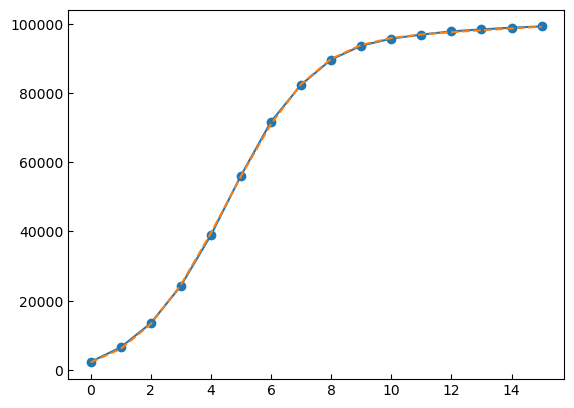

In [848]:
plt.plot(integrali_ism[1,:,0],marker='o')
plt.plot(integrali_ism[1,:,1],linestyle='dashed')
plt.tick_params(axis='both', direction= 'in')

## PROVE CORRELAZIONI

In [268]:
print(d3.shape)

(3, 512, 512, 50, 9)


In [629]:
#Definisco sequenza intensità ISM

ttrace_ism = np.zeros((3,512,512,50,9))

for i in tqdm(range(50)):
    ttrace_ism[0,:,:,i,:]=apr.Reassignment(shift3,d3[0,:,:,i,:])
    ttrace_ism[1,:,:,i,:]=apr.Reassignment(shift3,d3[1,:,:,i,:])
    ttrace_ism[2,:,:,i,:]=apr.Reassignment(shift3,d3[2,:,:,i,:])
ttrace_ism_sum=np.sum(ttrace_ism, axis=(-1))
print(ttrace_ism_sum.shape)

100%|██████████| 50/50 [00:26<00:00,  1.90it/s]


(3, 512, 512, 50)


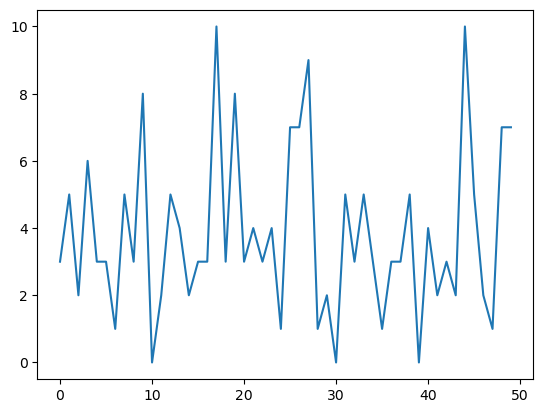

In [631]:
plt.plot(ttrace_ism_sum[0,440,332,:])

In [683]:
#SRRF sulla sequenza di intensità
srrf_ism_2_var = np.zeros((3,512,512))
srrf_ism_2_avg = np.zeros((3,512,512))
srrf_ism_2_tac = np.zeros((3,512,512))

for f in range(3):
    srrf_ism_sum_2= eSRRF(np.ascontiguousarray(np.transpose(ttrace_ism_sum[f,:,:,:],axes=(2,0,1))), magnification=1,radius=7)[0]
    srrf_ism_2_var[f,...] = calculate_eSRRF_temporal_correlations(srrf_ism_sum_2, 'VAR')
    srrf_ism_2_avg[f,...] = calculate_eSRRF_temporal_correlations(srrf_ism_sum_2, 'AVG')
    srrf_ism_2_tac[f,...] = calculate_eSRRF_temporal_correlations(srrf_ism_sum_2, 'TAC2')

Agent: eSRRF_ST using opencl ran in 0.5361392999766394 seconds
Agent: eSRRF_ST using opencl ran in 0.44599550002021715 seconds
Agent: eSRRF_ST using opencl ran in 0.4456903000245802 seconds


In [685]:
print(srrf_ism_2_tac.shape)

(3, 512, 512)


In [721]:
srrf_ism_2_var_mean = np.mean(srrf_ism_2_var, axis=0)
srrf_ism_2_avg_mean = np.mean(srrf_ism_2_avg, axis=0)
srrf_ism_2_tac_mean = np.abs(np.mean(srrf_ism_2_tac, axis=0))

(50, 512, 512)


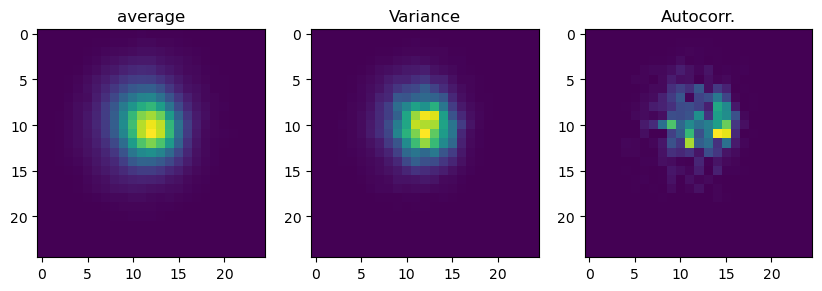

In [723]:
fig, ax = plt.subplots(1,3,figsize=(10,10))
ax0 = ax[0].imshow(srrf_ism_2_avg_mean[430:455, 320:345])
ax[0].set_title('average')
ax1= ax[1].imshow(srrf_ism_2_var_mean[430:455, 320:345])
ax[1].set_title('Variance')
ax2 = ax[2].imshow(srrf_ism_2_tac_mean[430:455, 320:345])
ax[2].set_title('Autocorr.')
print(srrf_ism_sum_2.shape)

In [621]:
def correla(t1,tau):
    corr_carota=0
    t1_b = t1 - np.mean(t1)
    
    for i in range(t1.shape[0]-tau):
        corr_carota += t1_b[i]*t1_b[i+tau]
    corr_carota /= t1.shape[0]-tau
    corr_carota /= np.mean(t1)**2
    return corr_carota

In [623]:
img_autocorr=np.zeros((512,512,2))
for i in tqdm(range(srrf_ism_sum_2.shape[1])):
    for j in range(srrf_ism_sum_2.shape[2]):
        for tau in range(2):
            img_autocorr[i,j,tau] = correla(srrf_ism_sum_2[:,i,j],tau)

  0%|          | 0/512 [00:00<?, ?it/s]C:\Users\rbolz\AppData\Local\Temp\ipykernel_20124\1192376834.py:8: RuntimeWarning: invalid value encountered in scalar divide
  corr_carota /= np.mean(t1)**2
100%|██████████| 512/512 [00:21<00:00, 24.08it/s]


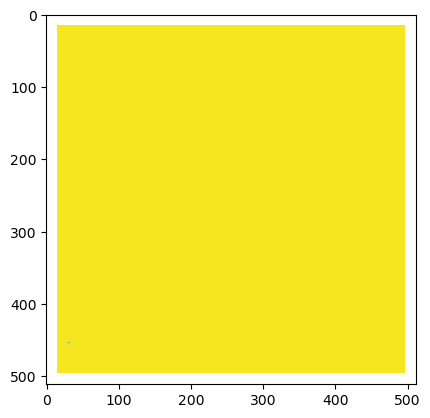

In [627]:
plt.imshow(img_autocorr[:,:,1])

In [329]:
#Correlazioni definite da noi

srrf_carota = srrf_ism_sum_2[:,441,334]
srrf_carota_delta = srrf_carota - np.mean(srrf_carota)
corr_carota=0

for i in range(srrf_carota.shape[0]-1):
    corr_carota += srrf_carota_delta[i]*srrf_carota_delta[i+1]
corr_carota /= srrf_carota.shape[0]-1
#corr_carota /= np.mean(srrf_carota)**2

print(corr_carota)
print(srrf_ism_2[441,334])

0.3954451900944874
0.39544517


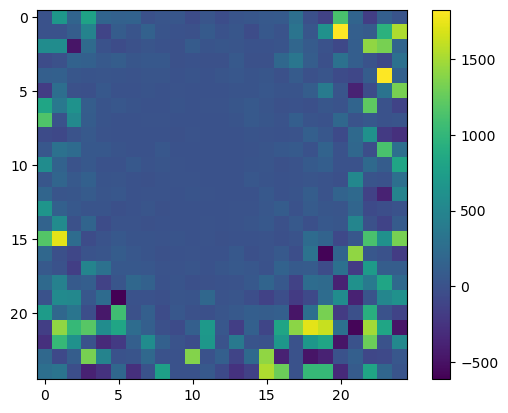

In [363]:
#Correlazioni con Scipy

test2 = np.zeros((ttrace_ism_sum.shape[0],ttrace_ism_sum.shape[1],ttrace_ism_sum.shape[2]))

for i in range(d3.shape[1]):
    for j in range(d3.shape[2]):
        m4 = np.mean(ttrace_ism_sum[i,j,:])
        test2[i,j,:] = scipy.signal.correlate(ttrace_ism_sum[i,j,:]-m4,ttrace_ism_sum[i,j,:]-m4, method='auto', mode='same')
        if m4==0: m4=1
        test2[i,j,:] /= m4**2
plt.imshow(test2[430:455, 320:345,:].sum(axis=2))
plt.colorbar()

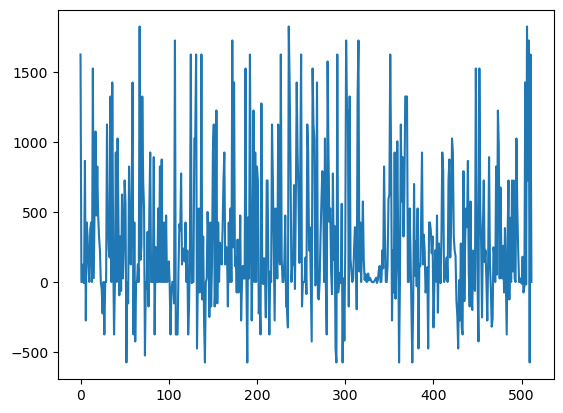

In [367]:
plt.plot(test2[440,:,:].sum(axis=1))

(100, 64, 64)
(64, 64, 100)


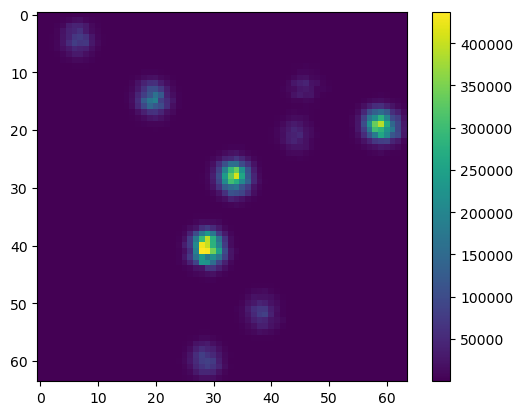

In [1211]:
## Temporal correlations su ISS

def correlazione(t1,m1,t2,m2):
    fft1=scipy.fftpack.fft([(t1[i])-m1 for i in range(len(t1))])
    fft2=scipy.fftpack.fft([(t2[i])-m2 for i in range(len(t2))])
    fft1=np.ma.conjugate(fft1)
    crosscorr=np.real(scipy.fftpack.ifft(fft1*fft2))#/(m1*m2*len(t1)))
    return crosscorr

central=tifffile.imread('/Users/margauxbouzin/Library/CloudStorage/GoogleDrive-margaux.bouzin@unimib.it/Drive condivisi/BioPhotonics/Margaux/ISS ISM/2025 07 07-08 Qdots/Qdots_FOV5um_64x64_5msPixel_23rip_37mW.tif')
#central=central[:23,:,:]
plt.imshow(central[10,:,:])
print(central.shape)

img_autocorr=np.zeros((central.shape[1],central.shape[2],central.shape[0]), dtype='float')
print(img_autocorr.shape)

for i in range(central.shape[1]):
    for j in range(central.shape[2]):
        count=0
        if np.mean(central[:,i,j])!=0:
                count=count+1
                img_autocorr[i,j,:]=img_autocorr[i,j,:]+correlazione(central[:,i,j],np.mean(central[:,i,j]),central[:,i,j],np.mean(central[:,i,j]))
        if count!=0:
            img_autocorr[i,j,:]=img_autocorr[i,j,:]/count
plt.imshow(img_autocorr[:,:,0])            
plt.colorbar()

Text(0.5, 1.0, 'ISM + time srrf')

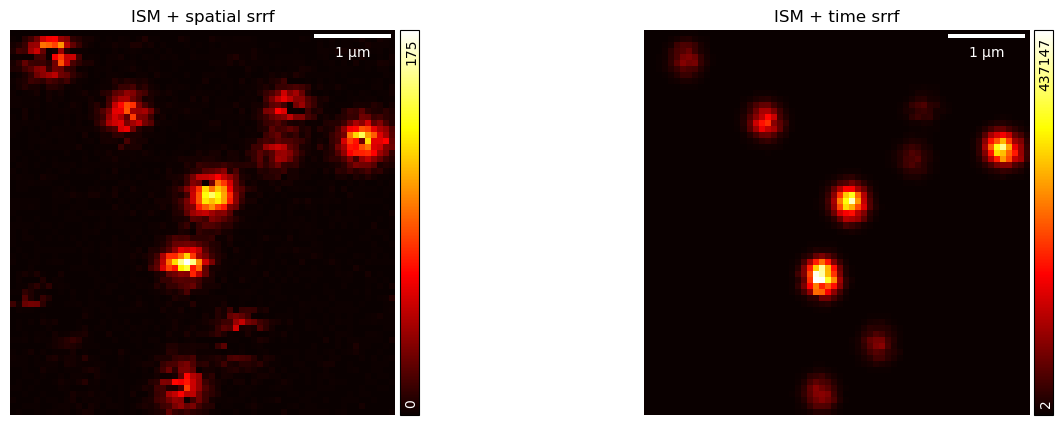

In [1213]:
fig, ax = plt.subplots(1, 2, figsize=(15,5))
gra.ShowImg(central[0,:,:], pxsize_x = pxsizex, fig = fig, ax = ax[0])
ax[0].set_title('ISM + spatial srrf')
gra.ShowImg(img_autocorr[:,:,0], pxsize_x = pxsizex, fig = fig, ax = ax[1])
#gra.PlotShiftVectors(shift_vec3, fig = fig, ax = ax[1],color='red',labels=False)
ax[1].set_title('ISM + time srrf')

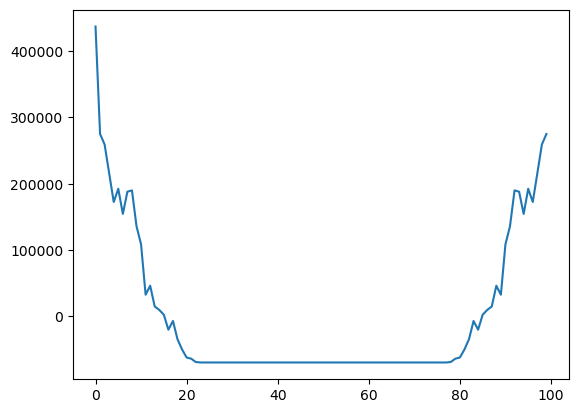

In [1215]:
plt.plot(np.arange(0,100,1),img_autocorr[41,28,:100])